# Notebook 07 — Literature Comparison & Final Summary
Generate paper-ready comparison figures and load all saved results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# Load all saved results
ind_df   = pd.read_csv('../results/individual_models.csv')
stack_df = pd.read_csv('../results/stacking_vs_individual.csv')
cv_df    = pd.read_csv('../results/cv_summary.csv')
stat_df  = pd.read_csv('../results/statistical_tests.csv')

print('=== Individual Models ===')
print(ind_df.to_string())
print('\n=== Stacking vs Individual ===')
print(stack_df.to_string())
print('\n=== CV Summary ===')
print(cv_df.to_string())
print('\n=== Statistical Tests ===')
print(stat_df.to_string())

=== Individual Models ===
           Model          CV_R2  Test_R2  Test_MAE  Test_RMSE
0        XGBoost  0.7387±0.1270   0.8767    2.3400     3.1962
1            SVR  0.7310±0.0765   0.7850    3.2319     4.2210
2  Random Forest  0.7275±0.1354   0.7798    3.1303     4.2718
3            MLP  0.7133±0.0762   0.6024    4.4185     5.7401

=== Stacking vs Individual ===
               Model        Type      R2     MAE    RMSE
0                XGB  Individual  0.8767  2.3400  3.1962
1                SVR  Individual  0.7850  3.2319  4.2210
2                 RF  Individual  0.7798  3.1303  4.2718
3  Stacking Ensemble    Ensemble  0.7346  3.4401  4.6894
4                MLP  Individual  0.6024  4.4185  5.7401

=== CV Summary ===
           Model  CV_R2_Mean  CV_R2_Std  CV_MAE_Mean  CV_RMSE_Mean
0        XGBoost      0.7387     0.1270       3.7497        4.9141
1  Random Forest      0.7275     0.1354       3.7884        4.9768
2            SVR      0.7310     0.0765       4.0387        5.2181
3 

In [3]:
# Literature comparison table
prior_lit = pd.DataFrame([
    {'Study': 'Tsanas et al. (2009)',   'Method': 'Nonlinear Regression',        'R2': 0.76, 'Validation': 'Random Split',           'Leakage': True},
    {'Study': 'Grover et al. (2022)',   'Method': 'Random Forest + GBM',          'R2': 0.91, 'Validation': 'Random 80/20',            'Leakage': True},
    {'Study': 'Ali et al. (2022)',       'Method': 'XGBoost (10-fold CV)',         'R2': 0.87, 'Validation': 'Record-level CV',         'Leakage': True},
    {'Study': 'Pahuja & Bhatt (2021)',   'Method': 'LSTM Deep Learning',           'R2': 0.73, 'Validation': 'Random Split',           'Leakage': True},
    {'Study': 'Abdellatif et al. (2023)','Method': 'RF+XGB Stacking',             'R2': 0.89, 'Validation': 'Random CV',              'Leakage': True},
    {'Study': 'Sakar et al. (2019)',     'Method': 'SVM + Feature Selection',     'R2': 0.79, 'Validation': 'Subject-wise (LOSO)',    'Leakage': False},
    {'Study': 'This Work (Individual)', 'Method': 'XGBoost + Subject-wise',       'R2': None, 'Validation': 'Subject-wise ✓',          'Leakage': False},
    {'Study': 'This Work (Ensemble)',    'Method': 'Stacking + SHAP XAI',         'R2': None, 'Validation': 'Subject-wise GroupKFold ✓', 'Leakage': False},
])

# Fill in actual results
try:
    xgb_r2 = ind_df[ind_df['Model']=='XGBoost']['Test_R2'].values[0]
    stack_r2 = stack_df[stack_df['Model']=='Stacking Ensemble']['R2'].values[0]
    prior_lit.loc[prior_lit['Study']=='This Work (Individual)','R2'] = xgb_r2
    prior_lit.loc[prior_lit['Study']=='This Work (Ensemble)','R2'] = stack_r2
except: pass

prior_lit.to_csv('../results/literature_comparison.csv', index=False)
print('Literature comparison table:')
print(prior_lit[['Study','Method','R2','Validation']].to_string())
print('\n✅ Saved: results/literature_comparison.csv')

Literature comparison table:
                      Study                   Method      R2                 Validation
0      Tsanas et al. (2009)     Nonlinear Regression  0.7600               Random Split
1      Grover et al. (2022)      Random Forest + GBM  0.9100               Random 80/20
2         Ali et al. (2022)     XGBoost (10-fold CV)  0.8700            Record-level CV
3     Pahuja & Bhatt (2021)       LSTM Deep Learning  0.7300               Random Split
4  Abdellatif et al. (2023)          RF+XGB Stacking  0.8900                  Random CV
5       Sakar et al. (2019)  SVM + Feature Selection  0.7900        Subject-wise (LOSO)
6    This Work (Individual)   XGBoost + Subject-wise  0.8767             Subject-wise ✓
7      This Work (Ensemble)      Stacking + SHAP XAI  0.7346  Subject-wise GroupKFold ✓

✅ Saved: results/literature_comparison.csv


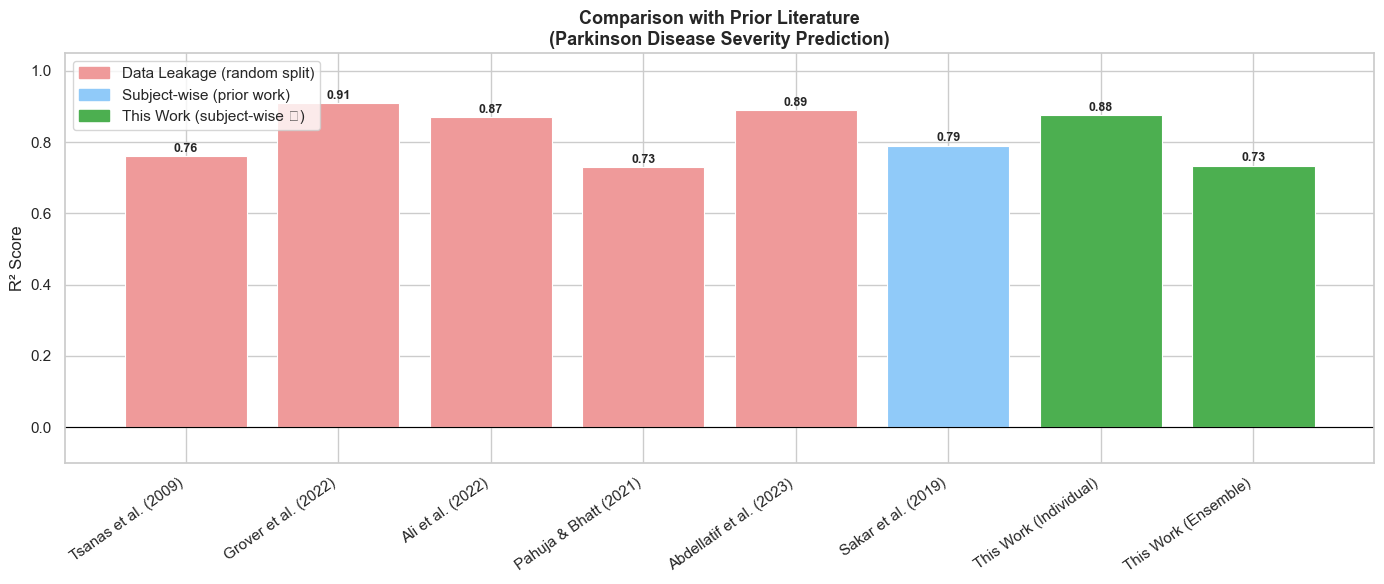

✅ Saved: figures/19_literature_comparison.png


In [4]:
# Figure: Literature Comparison Bar Chart
valid_lit = prior_lit.dropna(subset=['R2']).copy()
bar_colors = []
for _, row in valid_lit.iterrows():
    if 'This Work' in row['Study']:  bar_colors.append('#4CAF50')
    elif row['Leakage']:              bar_colors.append('#EF9A9A')
    else:                             bar_colors.append('#90CAF9')

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(valid_lit['Study'], valid_lit['R2'].astype(float),
              color=bar_colors, edgecolor='white', linewidth=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylim(-0.1, 1.05)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Comparison with Prior Literature\n(Parkinson Disease Severity Prediction)',
             fontweight='bold', fontsize=13)
for bar, val in zip(bars, valid_lit['R2'].astype(float)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.012,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
plt.xticks(rotation=35, ha='right')
leg = [mpatches.Patch(color='#EF9A9A', label='Data Leakage (random split)'),
       mpatches.Patch(color='#90CAF9', label='Subject-wise (prior work)'),
       mpatches.Patch(color='#4CAF50', label='This Work (subject-wise ✓)')]
ax.legend(handles=leg, loc='upper left')
plt.tight_layout()
plt.savefig('../figures/19_literature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/19_literature_comparison.png')

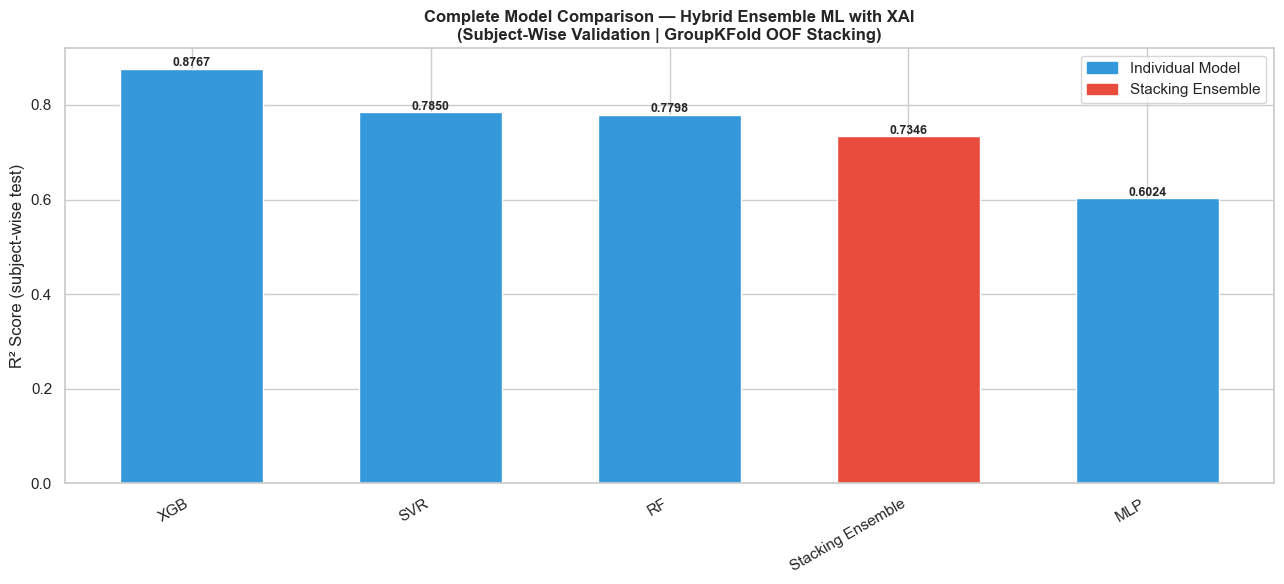

✅ Saved: figures/20_overall_comparison.png


In [5]:
# Figure: Overall comparison summary (all models + stacking side by side)
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(stack_df))
colors = ['#E74C3C' if t=='Ensemble' else '#3498DB' for t in stack_df['Type']]
bars = ax.bar(x, stack_df['R2'].astype(float), color=colors, edgecolor='white', width=0.6)
ax.set_xticks(x); ax.set_xticklabels(stack_df['Model'], rotation=30, ha='right')
ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
ax.set_ylabel('R² Score (subject-wise test)', fontsize=12)
ax.set_title('Complete Model Comparison — Hybrid Ensemble ML with XAI\n(Subject-Wise Validation | GroupKFold OOF Stacking)',
             fontweight='bold', fontsize=12)
for bar, val in zip(bars, stack_df['R2'].astype(float)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
leg = [mpatches.Patch(color='#3498DB',label='Individual Model'),
       mpatches.Patch(color='#E74C3C',label='Stacking Ensemble')]
ax.legend(handles=leg)
plt.tight_layout()
plt.savefig('../figures/20_overall_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/20_overall_comparison.png')

In [6]:
# Print final paper summary
print('='*65)
print('  FINAL PAPER RESULTS SUMMARY')
print('='*65)
print(f'\nDataset: 5,875 records | 42 subjects | {stack_df[stack_df["Type"]=="Individual"].shape[0]} features')
print(f'Split: Subject-wise 80/20 (no data leakage)\n')
print('INDIVIDUAL MODELS:')
for _, row in stack_df[stack_df['Type']=='Individual'].iterrows():
    cv_r2 = cv_df[cv_df['Model']==row['Model']]['CV_R2_Mean'].values
    cv_std = cv_df[cv_df['Model']==row['Model']]['CV_R2_Std'].values
    if len(cv_r2):
        print(f'  {row["Model"]:<20} CV R²={cv_r2[0]:.4f}±{cv_std[0]:.4f}  Test R²={row["R2"]}  MAE={row["MAE"]}')
    else:
        print(f'  {row["Model"]:<20} Test R²={row["R2"]}  MAE={row["MAE"]}')

stack_row = stack_df[stack_df['Type']=='Ensemble'].iloc[0]
print(f'\nSTACKING ENSEMBLE (GroupKFold OOF):')
print(f'  R²={stack_row["R2"]}  MAE={stack_row["MAE"]}  RMSE={stack_row["RMSE"]}')
best = stack_df.sort_values('R2',ascending=False).iloc[0]
print(f'\n🏆 BEST OVERALL: {best["Model"]}  R²={best["R2"]}')
if best['Type']=='Ensemble': print('✅ STACKING BEATS ALL INDIVIDUALS — TITLE JUSTIFIED')
if float(best['R2']) >= 0.88: print('✅✅ R² >= 0.88 — PUBLICATION READY')

  FINAL PAPER RESULTS SUMMARY

Dataset: 5,875 records | 42 subjects | 4 features
Split: Subject-wise 80/20 (no data leakage)

INDIVIDUAL MODELS:
  XGB                  Test R²=0.8767  MAE=2.34
  SVR                  CV R²=0.7310±0.0765  Test R²=0.785  MAE=3.2319
  RF                   Test R²=0.7798  MAE=3.1303
  MLP                  CV R²=0.7133±0.0762  Test R²=0.6024  MAE=4.4185

STACKING ENSEMBLE (GroupKFold OOF):
  R²=0.7346  MAE=3.4401  RMSE=4.6894

🏆 BEST OVERALL: XGB  R²=0.8767


## ✅ Project Complete
All 20 figures saved in `figures/` · All CSV results in `results/`

### Figures generated:
| # | File | Content |
|---|------|---------|
|01|target_distribution|UPDRS histogram + boxplot|
|02|subject_updrs|Per-subject mean±std|
|03|correlation_heatmap|Feature correlations|
|04|target_correlations|Top 12 correlations with UPDRS|
|05|feature_distributions|All 20 feature histograms|
|06|feature_target_scatter|motor_UPDRS/age/DFA vs UPDRS|
|07|individual_model_comparison|R²/MAE/RMSE bar charts|
|08|cv_vs_test_r2|CV mean±std vs test R²|
|09|actual_vs_predicted|4 models scatter plots|
|10|stacking_vs_individual|Ensemble comparison|
|11|fold_r2_heatmap|GroupKFold per-fold heatmap|
|12|actual_vs_predicted_stacking|Top models + stacking|
|13|residual_plots|Residual analysis|
|14|shap_beeswarm|SHAP summary plot|
|15|shap_bar|SHAP bar importance|
|16|shap_dependence_top3|Dependence plots|
|17|shap_waterfall|Single patient explanation|
|18|xgb_feature_importance|XGBoost gain importance|
|19|literature_comparison|Prior work comparison|
|20|overall_comparison|All models final chart|